In [ ]:
import keras_cv
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf

In [4]:
print("Available devices: \n")
for device in tf.config.list_logical_devices():
    print(device.name, device.device_type)

Available devices: 

/device:CPU:0 CPU


2025-11-10 19:12:58.635811: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
def get_strategy():
    """
    Detects and returns the best TensorFlow distribution strategy.
    - TPUStrategy for TPU(s)
    - MirroredStrategy for GPU(s)
    - Default strategy for CPU
    """
    try:
        # Try TPU first
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print("Using TPU strategy:", type(strategy).__name__)
    except Exception:
        # If TPU not available, try GPU
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            strategy = tf.distribute.MirroredStrategy()
            print("Using GPU strategy:", type(strategy).__name__)
        else:
            # Fallback CPU
            strategy = tf.distribute.get_strategy()
            print("No TPU/GPU found. Using CPU strategy:", type(strategy).__name__)

    print("REPLICAS:", strategy.num_replicas_in_sync)
    return strategy

# Call it
strategy = get_strategy()

INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local
No TPU/GPU found. Using CPU strategy: _DefaultDistributionStrategy
REPLICAS: 1


In [6]:
DATA_DIR = '/kaggle/input/global-wheat-detection'
MODEL_DIR = '/kaggle/input/wheat-detection/keras/warmup/3/finetune_best_model.keras'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')
CSV_PATH = os.path.join(DATA_DIR, 'train.csv')

In [7]:
with strategy.scope():
    print("Loading model ...")
    yolo_model = tf.keras.models.load_model(MODEL_DIR,
            custom_objects = {
                'YOLOV8Detector': keras_cv.models.YOLOV8Detector,
                'YOLOV8Backbone': keras_cv.models.YOLOV8Backbone
            }
    )
    print("Model loaded successfully. Ready for Visualization and Test Time !")

Loading model ...


/usr/local/lib/python3.11/dist-packages/keras/src/saving/serialization_lib.py:734: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


Model loaded successfully. Ready for Visualization and Test Time !


In [8]:
IMG_SIZE = (1024, 1024)
NUM_CLASSES = 1
NUM_TTA = 8
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5
AUTO = tf.data.AUTOTUNE
BATCH_SIZE_PER_REPLICA = 4
BUFFER_SHUFFLE_SIZE = 512
BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync
print(f'Global Batch size: {BATCH_SIZE}')

Global Batch size: 4


In [9]:
def preprocess_for_inference(image_path):
    """Loads and resizes a single image for model prediction."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image_id = tf.strings.split(image_path, os.sep)[-1]       # filename
    image_id = tf.strings.regex_replace(image_id, ".jpg$", "") # remove extension
    return image, image_id

In [44]:
fnames = os.listdir(TRAIN_DIR)[:4]
train_image_paths = [os.path.join(TRAIN_DIR, fname) for fname in fnames]
train_ds_vis = tf.data.Dataset.from_tensor_slices(train_image_paths)
train_ds_vis = (train_ds_vis.map(preprocess_for_inference, num_parallel_calls= AUTO)
                            .batch(BATCH_SIZE)
               )

train_ds_vis = train_ds_vis.map(lambda image, image_id: image, num_parallel_calls= AUTO)
preds = yolo_model.predict(train_ds_vis)
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
{'boxes': array([[[ 2.53356812e+02,  2.45655243e+02,  3.23440613e+02,
          3.35981476e+02],
        [ 8.88664429e+02,  7.58276123e+02,  1.02374957e+03,
          8.38021729e+02],
        [ 5.87958435e+02,  2.58236572e+02,  6.63701416e+02,
          3.56009552e+02],
        ...,
        [ 9.90311584e+02, -2.61588573e-01,  1.02411646e+03,
          4.92757301e+01],
        [ 4.52816772e+02,  6.05965088e+02,  5.34871643e+02,
          6.99334167e+02],
        [ 6.49517151e+02,  8.45663940e+02,  7.21582825e+02,
          9.10112488e+02]],

       [[ 1.20509560e+02,  3.44718323e+02,  1.88062073e+02,
          4.13381714e+02],
        [ 3.59884216e+02,  5.20167969e+02,  4.41351044e+02,
          6.11344604e+02],
        [-9.56420898e-02,  3.32848740e+01,  9.24778748e+01,
          1.18969193e+02],
        ...,
        [ 7.26940735e+02,  8.33130859e+02,  7.76876343e+02,
          8.81262207e+02],
        [ 7.32337280e+02,  5.07880280e+02,  7.79931396

In [10]:
def visualize_detections(model, dataset, bounding_box_format="xyxy", 
                         confidence_threshold=CONF_THRESHOLD):
    # Take one batch of images (already preprocessed)
    batch = next(iter(dataset))
    images = batch  # your dataset already yields images

    # Run model inference on the batch
    y_pred = model.predict(images)

    # y_pred is a dictionary: {'boxes': ..., 'confidence': ..., 'classes': ...}
    # Filter low-confidence boxes manually (since keras_cv.bounding_box has no filter)
    conf_mask = y_pred["confidence"] > confidence_threshold

    # Create filtered prediction dict
    y_pred_filtered = {
        "boxes": tf.ragged.boolean_mask(y_pred["boxes"], conf_mask),
        "classes": tf.ragged.boolean_mask(y_pred["classes"], conf_mask),
        "confidence": tf.ragged.boolean_mask(y_pred["confidence"], conf_mask),
    }

    # Visualize with KerasCV utility
    keras_cv.visualization.plot_bounding_box_gallery(
        images,
        value_range=(0, 255),
        bounding_box_format=bounding_box_format,
        y_pred=y_pred_filtered,
        scale=4,
        rows=2,
        cols=2,
        show=True,
        font_scale=0.7,
    )


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


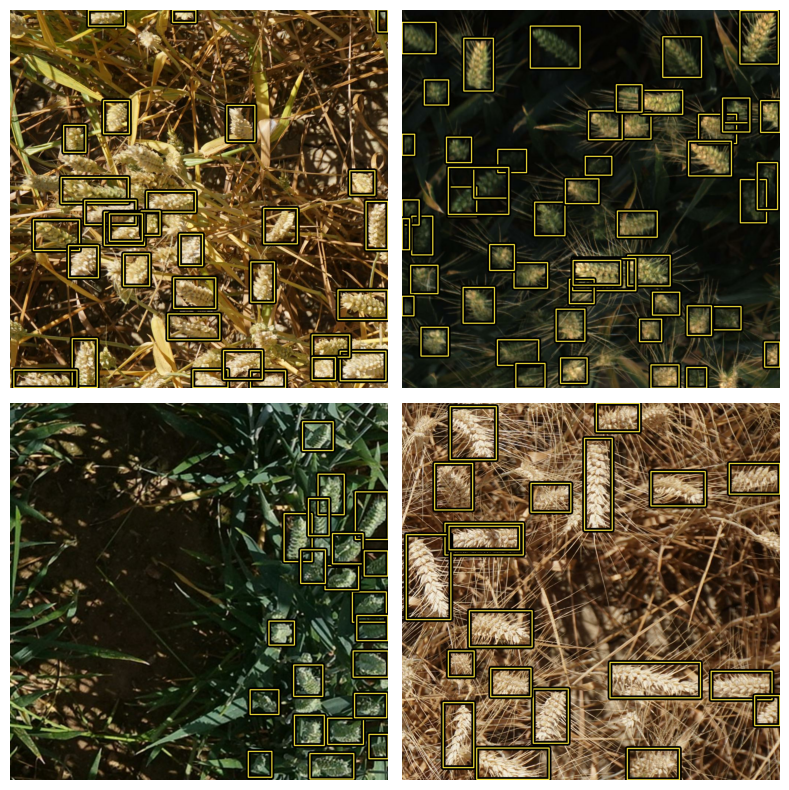

In [16]:
visualize_detections(yolo_model, train_ds_vis, bounding_box_format="xyxy")

In [11]:
def test_dataset(TEST_DIR):
    test_images_path = [
        os.path.join(TEST_DIR, fname) for fname in os.listdir(TEST_DIR)
    ]
    test_ds = tf.data.Dataset.from_tensor_slices(test_images_path)
    test_ds = (test_ds.map(preprocess_for_inference, num_parallel_calls= AUTO)
                      .batch(BATCH_SIZE)
                      .prefetch(AUTO))
    
    print('Test Dataset created successfully !')
    return test_ds
    

In [12]:
test_ds = test_dataset(TEST_DIR)

Test Dataset created successfully !


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


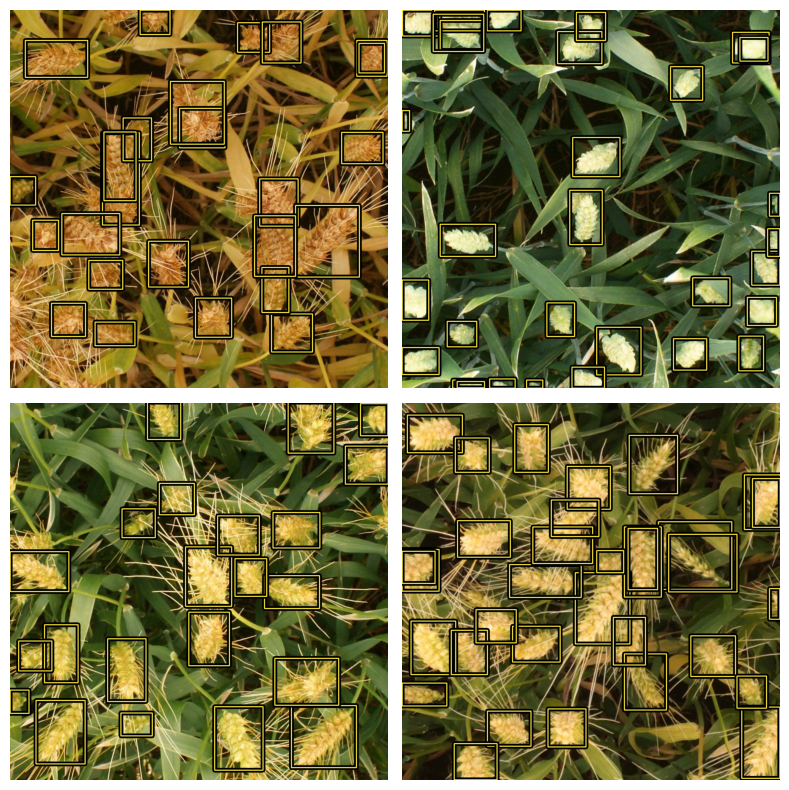

In [55]:
test_ds_vis = test_ds.map(lambda image, image_id: image, num_parallel_calls= AUTO)
visualize_detections(yolo_model, test_ds_vis)

In [15]:
# Light reversible augmentations for TTA
tta_augmenter = tf.keras.Sequential([
    keras_cv.layers.JitteredResize(
        target_size=IMG_SIZE, scale_factor=(0.95, 1.05), bounding_box_format="xyxy"
    ),
    keras_cv.layers.RandomFlip(
        mode="horizontal", bounding_box_format="xyxy"
    ),
    keras_cv.layers.RandomColorJitter(
        value_range=(0.0, 255.0),
        brightness_factor=0.05, contrast_factor=0.05,
        saturation_factor=0.05, hue_factor=0.02
    ),
], name="tta_augmenter")

In [16]:
def tta_inference_batch(model, images, num_tta=NUM_TTA):
    all_boxes, all_scores, all_classes = [], [], []

    for _ in range(num_tta):
        augmented = tta_augmenter(
            {"images": images, "bounding_boxes": {
                "boxes": tf.zeros((tf.shape(images)[0], 1, 4)),  # dummy boxes
                "classes": tf.zeros((tf.shape(images)[0], 1)),
            }},
            training=True
        )["images"]

        preds = model.predict(augmented, verbose=0)

        all_boxes.append(preds["boxes"])
        all_scores.append(preds["confidence"])
        all_classes.append(preds["classes"])

    boxes = tf.concat(all_boxes, axis=1)
    scores = tf.concat(all_scores, axis=1)
    classes = tf.concat(all_classes, axis=1)

    final_boxes, final_scores, final_classes, _ = tf.image.combined_non_max_suppression(
        boxes=boxes,
        scores=scores,
        max_output_size_per_class=200,
        max_total_size=200,
        iou_threshold=IOU_THRESHOLD,
        score_threshold=CONF_THRESHOLD
    )

    return final_boxes.numpy(), final_scores.numpy(), final_classes.numpy()

In [ ]:
# ----------------------------
# Pick a small batch for quick testing
# ----------------------------
for images, ids in test_ds.take(1):  # just take the first batch
    print("Original batch shape:", images.shape)

    # Run TTA inference on the batch
    boxes_batch, scores_batch, classes_batch = tta_inference_batch(yolo_model, images, num_tta=4)

    print("Boxes batch shape:", boxes_batch.shape)
    print("Scores batch shape:", scores_batch.shape)
    print("Classes batch shape:", classes_batch.shape)

    # Print the first image predictions for inspection
    print("\nFirst image predictions:")
    for i in range(len(boxes_batch[0])):
        x1, y1, x2, y2 = boxes_batch[0][i]
        score = scores_batch[0][i]
        cls = classes_batch[0][i]
        if score < 0.25:
            continue
        print(f"Class {cls} | Score {score:.3f} | Box [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")


Original batch shape: (4, 1024, 1024, 3)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(4, 1024, 1024, 3))
  warnings.warn(msg)
